# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB



#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.



In [3]:
# mostrar las primeras 5 filas
df.head(5)


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

Corregir tipos de datos
- Convertimos id_cliente a string para evitar que sea tomado como número accidentalmente.
- Aseguramos que las variables binarias sean enteros 'miembro_premium', 'abandono'.

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 'nivel_ingreso'
- 'visitas_mes'
- 'compras_mes'
- 'gasto_publicidad_dirigida'
- 'satisfaccion'
- 'ingreso_anual'

La mayoría presentan tipos adecuados (float64 e int64)

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
# Convertimos id_cliente a string para evitar que sea tomado como número accidentalmente
df['id_cliente'] = df['id_cliente'].astype(str)

# Aseguramos que las variables binarias sean enteros
df['miembro_premium'] = df['miembro_premium'].astype(int)
df['abandono'] = df['abandono'].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
# Seleccionamos solo las variables cuantitativas para evitar promedios en IDs o binarias
cols_analisis = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Generamos el resumen y transponemos para facilitar la lectura
resumen_stats = df[cols_analisis].describe().T
print(resumen_stats)

                             count          mean          std     min  \
edad                       15000.0     38.262400    11.492378    18.0   
nivel_ingreso              15000.0  30019.704782  9833.166305  8000.0   
visitas_mes                15000.0     10.029000     3.158189     1.0   
compras_mes                15000.0      1.206467     1.105284     0.0   
gasto_publicidad_dirigida  15000.0     20.149301    10.880724     0.0   
satisfaccion               15000.0      3.603693     0.685300     1.0   
ingreso_anual              15000.0     36.594180    34.484888     0.0   

                                  25%        50%         75%       max  
edad                          30.0000     38.000     46.0000     75.00  
nivel_ingreso              23127.0975  30023.745  36768.4400  74790.84  
visitas_mes                    8.0000     10.000     12.0000     25.00  
compras_mes                    0.0000      1.000      2.0000      8.00  
gasto_publicidad_dirigida     12.3100     19.730  

✍️ **Comentario**: 
Diagnóstico inicial de variables numéricas

- `edad` — El promedio se sitúa alrededor de los 38 años.
- 'nivel_ingreso'- Presenta una dispersión alta.
- 'visitas_mes' - Es una variable con alta frecuencia.
- 'compras_mes' - Es la variable de conversión.
- 'gasto_publicidad_dirigida'- Es probable que tenga una distribución sesgada; muchos usuarios con poco gasto publicitario y un segmento específico con campañas agresivas.
- 'satisfaccion' Al ser una escala 1-5, lo más relevante es ver la mediana.
- 'ingreso_anual' - Es la variable con mayor variabilidad. Hay que resaltar la diferencia entre el valor mínimo (que puede ser 0) y el máximo, ya que los outliers aquí definirán qué tan segmentada debe ser la estrategia de retención.
  

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
# 1. Identificamos columnas con exactamente 2 valores únicos
columnas_binarias = [col for col in df if df[col].nunique() == 2]

print(f"Columnas con 2 valores únicos: {columnas_binarias}\n")

# 2. Verificamos el contenido de cada una
for col in columnas_binarias:
    valores = df[col].unique()
    print(f"Columna: '{col}'")
    print(f"  - Valores encontrados: {valores}")
    print(f"  - Conteo:\n{df[col].value_counts()}")
    print("-" * 30)

Columnas con 2 valores únicos: ['miembro_premium', 'abandono']

Columna: 'miembro_premium'
  - Valores encontrados: [0 1]
  - Conteo:
0    12911
1     2089
Name: miembro_premium, dtype: int64
------------------------------
Columna: 'abandono'
  - Valores encontrados: [0 1]
  - Conteo:
0    12739
1     2261
Name: abandono, dtype: int64
------------------------------


✍️ **Comentario**: 

Diagnóstico inicial de variables binarias

- `miembro_premium` — 
- `abandono` —

Las columnas binarias están limpias y listas. No hay valores extraños como un 2 o un nulo disfrazado.

#### Explorar variables categóricas

In [10]:
# Verificar el número de valores únicos por variable categórica
# 1. Identificar solo las columnas categóricas (tipo object)
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables categóricas detectadas: {categoricas}\n")

# 2. Verificar número de valores únicos y ejemplos
for col in categoricas:
    n_unicos = df[col].nunique()
    print(f"Columna: '{col}'")
    print(f"  - Cantidad de valores únicos: {n_unicos}")


Variables categóricas detectadas: ['id_cliente', 'tipo_dispositivo', 'region']

Columna: 'id_cliente'
  - Cantidad de valores únicos: 15000
Columna: 'tipo_dispositivo'
  - Cantidad de valores únicos: 3
Columna: 'region'
  - Cantidad de valores únicos: 4


In [13]:
# Explorar variables categóricas y cómo se distribuyen
# 1. Identificar las columnas categóricas
cols_cat = df.select_dtypes(include=['object']).columns

for col in cols_cat:
    n_unicos = df[col].nunique()
    print(f"### Análisis de la columna: {col} ###")
    print(f"Valores únicos: {n_unicos}")
    
    # Si es una columna con pocos valores (como region o dispositivo)
    if n_unicos < 20:
        # Calculamos frecuencia absoluta y relativa (%)
        frecuencias = df[col].value_counts()
        porcentajes = df[col].value_counts(normalize=True) * 100
        
        # Creamos un pequeño dataframe para mostrarlo limpio
        distribucion = pd.DataFrame({
            'Cantidad': frecuencias,
            'Porcentaje (%)': porcentajes.round(2)
        })
        print(distribucion)
    else:
        # Si es el ID de cliente o algo con muchos valores
        print(f"La columna tiene alta cardinalidad ({n_unicos} valores).")
        print(f"Primeros 5 valores: {df[col].unique()[:5]}")
    
    print("-" * 40 + "\n")


### Análisis de la columna: id_cliente ###
Valores únicos: 15000
La columna tiene alta cardinalidad (15000 valores).
Primeros 5 valores: ['CL-100000' 'CL-100001' 'CL-100002' 'CL-100003' 'CL-100004']
----------------------------------------

### Análisis de la columna: tipo_dispositivo ###
Valores únicos: 3
            Cantidad  Porcentaje (%)
móvil           9818           65.45
escritorio      3720           24.80
tablet          1462            9.75
----------------------------------------

### Análisis de la columna: region ###
Valores únicos: 4
       Cantidad  Porcentaje (%)
norte      4395           29.30
oeste      3810           25.40
sur        3726           24.84
este       3069           20.46
----------------------------------------



✍️ **Comentario**: 

Diagnóstico inicial de variables categóricas

1. id_cliente (Identificador Único). Tiene exactamente 15,000 valores únicos, lo que coincide con el número total de filas del dataset.

2. tipo_dispositivo (Comportamiento Tecnológico): Hay una clara dominancia del acceso móvil.

3. region (Distribución Geográfica): La distribución es bastante equilibrada entre las 4 zonas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

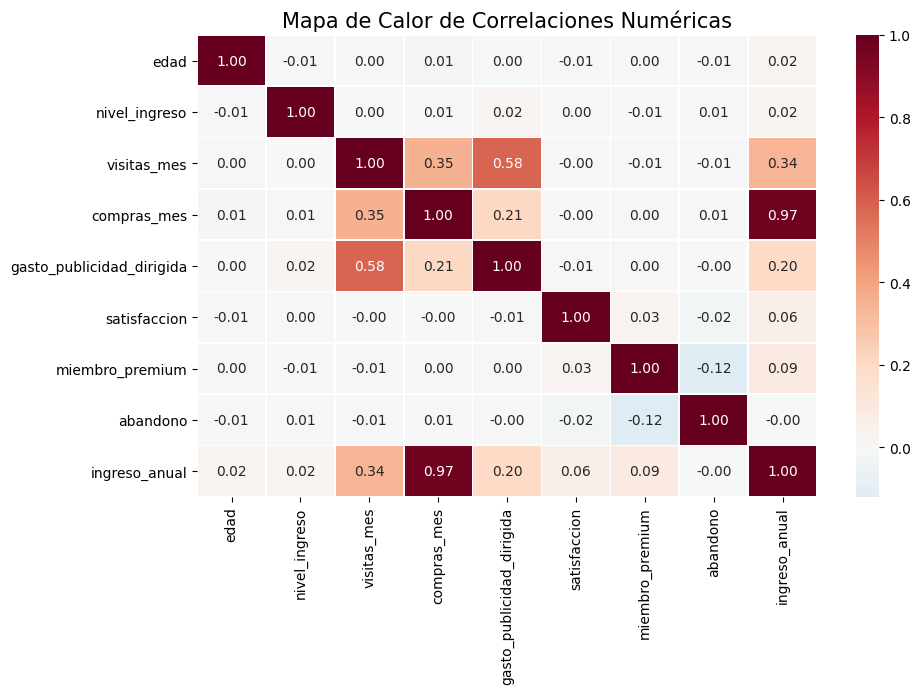

In [18]:
# Visualizar la matriz de correlación para identificar relaciones
# 1. Seleccionamos solo las columnas numéricas
# (Incluimos las binarias como 'abandono' para ver qué influye en la fuga)
cols_num = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[cols_num].corr()

# 2. Configuración del gráfico
plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",        
            cmap='RdBu_r',    # Rojo (negativo), Azul (positivo)
            center=0,         # El blanco es 0 (sin correlación)
            linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=15)
plt.show()

✍️ **Comentario**: 

Observaciones generales (Heatmap)  
- Independencia Socio - demográfica: Se observa que variables como edad y nivel_ingreso tienen correlaciones cercanas a cero (0.00 a 0.02) con el resto de las métricas. Esto sugiere que el comportamiento en la plataforma es independiente del perfil sociodemográfico del usuario.

- Relación Publicidad-Visitas: Existe una correlación moderada-alta (0.58) entre gasto_publicidad_dirigida y visitas_mes. Esto indica que la inversión publicitaria es efectiva para atraer tráfico a la aplicación, aunque no garantiza por sí sola la conversión final.

- Baja influencia de la Satisfacción: La variable satisfaccion no muestra una conexión fuerte con ninguna otra métrica (máximo 0.06), lo que implica que un cliente "satisfecho" no es necesariamente un cliente que compra más o visita más la plataforma.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva con compras_mes (0.97). Este es el hallazgo es lógico ya que el ingreso anual depende netamente de las compras mensuale, por lo que no es un hallazgo sorprendente.

- Visitas: A diferencia de las compras, las visitas_mes (0.34) tienen una relación mucho más débil con el ingreso. Muchos usuarios pueden navegar (posiblemente atraídos por la publicidad), pero solo un subgrupo convierte ese tráfico en valor monetario real.

- La correlación con miembro_premium (0.09) es positiva pero insignificante. Esto sugiere que el programa de suscripción actual no está logrando que esos usuarios generen un ingreso anual sustancialmente mayor que los usuarios estándar.


### Scatterplot general

**Scatterplot general**

- Decisión: No incluir un scatterplot general.
En un conjunto de datos con 15,000 registros y múltiples variables, un scatterplot general resulta ineficiente y difícil de interpretar por Saturación visual, baja utilidad de la mayoría de los pares, como observamos en el Heatmap, la mayoría de las variables (como edad, satisfaccion o nivel_ingreso) no tienen correlación entre sí. Generar gráficos para estos pares solo añadiría "ruido" visual al reporte sin aportar insights de negocio.

Se propone en su lugar añadir Scatterplots para pares clave enfocándonos exclusivamente en las relaciones que el Heatmap identificó como significativas: compras_mes vs ingreso_anual (0.97) y visitas_mes vs gasto_publicidad_dirigida (0.58).

### Scatterplot para pares clave

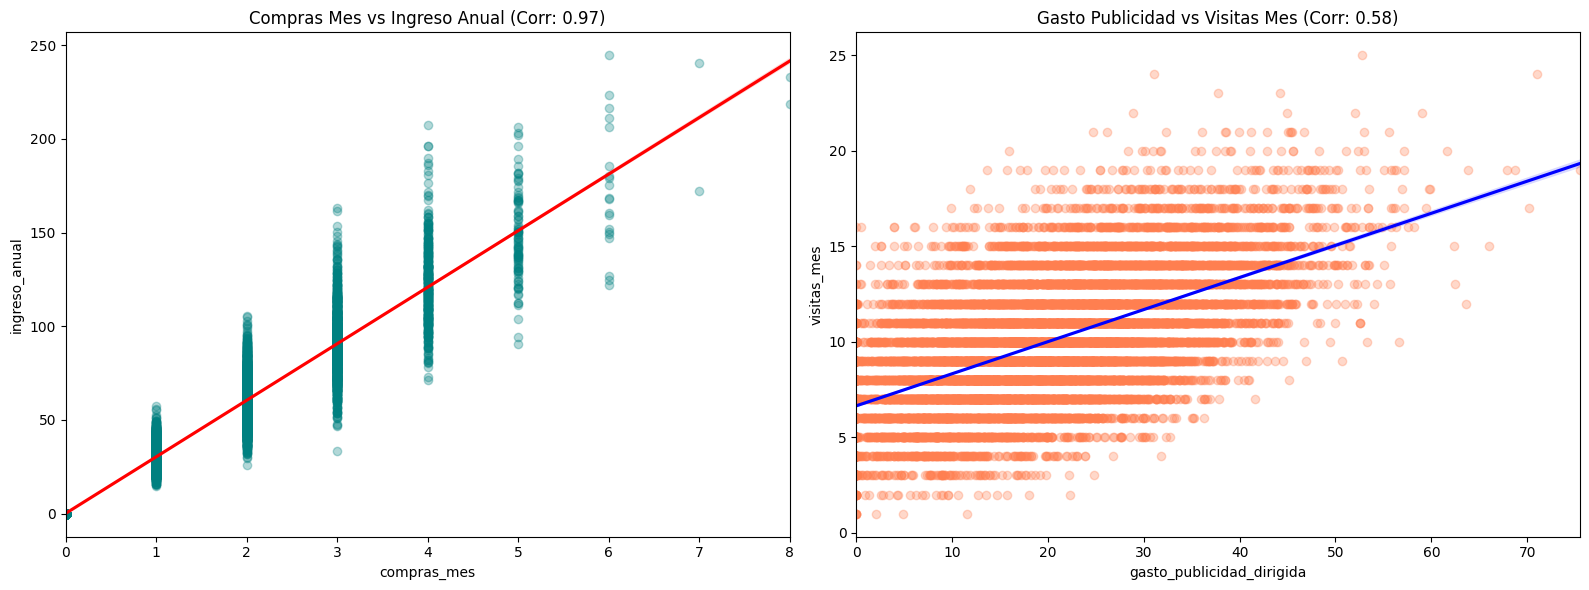

In [3]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Configuramos el área de dibujo para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: El driver principal de ingresos
sns.regplot(data=df, x='compras_mes', y='ingreso_anual', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Compras Mes vs Ingreso Anual (Corr: 0.97)')

# Gráfico 2: La efectividad de la publicidad
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', 
            scatter_kws={'alpha':0.3, 'color':'coral'}, 
            line_kws={'color':'blue'}, ax=axes[1])
axes[1].set_title('Gasto Publicidad vs Visitas Mes (Corr: 0.58)')

plt.tight_layout()
plt.show()

✍️ **Comentario**: 
Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**

- Dirección: Positiva y fuertemente lineal. Se observa que a medida que aumentan las compras mensuales, el ingreso anual sube de forma constante.

- Dispersión: Baja. Los puntos están muy pegados a la línea de regresión roja, lo que confirma una correlación de 0.97. Esto significa que casi todo el ingreso anual se explica solo con esta variable.

- Presencia de Outliers: Se observan muy pocos. El patrón es tan consistente que incluso los usuarios que compran mucho (extremo derecho) siguen la misma línea que los de compras bajas.

Posible Colinealidad: Para un modelo predictivo, estas variables serían redundantes.


**gasto_publicidad_dirigida vs visitas_mes**
- Dirección: Positiva. Existe una tendencia donde a mayor inversión publicitaria, mayor es el número de visitas.

- Dispersión: Media-Alta. A diferencia del primer gráfico, aquí los puntos forman una "nube" más ancha alrededor de la línea azul.

Interpretación: La correlación de 0.58 es significativa, pero indica que la publicidad no afecta a todos los usuarios por igual. Algunos usuarios visitan mucho la plataforma con poca inversión, mientras que otros requieren más gasto para generar tráfico. No hay una relación tan "rígida" como en las compras.



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [4]:
# Calcular correlación entre variables relevantes
# Selección de variables cuantitativas clave
cols_analisis = ['ingreso_anual', 'compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida', 'edad', 'satisfaccion']

# Cálculo de Pearson
pearson_result = df[cols_analisis].corr(method='pearson')['ingreso_anual'].sort_values(ascending=False)

# Cálculo de Spearman
spearman_result = df[cols_analisis].corr(method='spearman')['ingreso_anual'].sort_values(ascending=False)

# Consolidación en un solo DataFrame para comparar
evidencia_numerica = pd.DataFrame({
    'Pearson': pearson_result,
    'Spearman': spearman_result
})

print("Evidencia numérica de correlaciones respecto a ingreso_anual:")
print(evidencia_numerica)

Evidencia numérica de correlaciones respecto a ingreso_anual:
                            Pearson  Spearman
ingreso_anual              1.000000  1.000000
compras_mes                0.967149  0.967482
visitas_mes                0.337147  0.320954
gasto_publicidad_dirigida  0.197483  0.184999
satisfaccion               0.056171  0.060834
edad                       0.017496  0.016097


✍️ **Comentario**: 

Observaciones de correlación

**ingreso_anual vs compras_mes**

- Correlación: Presenta una magnitud de 0.967 (muy alta) y una dirección positiva.

- Interpretación: Al ser casi 1.0, indica que el ingreso anual es un reflejo directo del volumen transaccional mensual.

- Colinealidad: Existe una colinealidad extrema. En términos de modelado, estas dos variables comparten casi la misma información, por lo que usar ambas para predecir otra métrica sería redundante.

**ingreso_anual vs visitas_mes**

- Correlación: Presenta una magnitud de 0.337 (moderada) y una dirección positiva.

- Interpretación: Aunque el tráfico a la plataforma ayuda, no garantiza el ingreso en la misma proporción que las compras. Hay un componente de "navegación" que no siempre culmina en una transacción de alto valor.

**ingreso_anual vs gasto_publicidad_dirigida**

- Correlación: Presenta una magnitud de 0.197 (baja) y una dirección positiva.

- Interpretación: La inversión publicitaria tiene un impacto marginal en el ingreso directo por usuario. Su fuerza real probablemente reside en atraer visitas (visto en el 0.58 anterior), pero el cierre de la venta depende de otros factores de retención.

**ingreso_anual vs satisfaccion**

- Correlación: Presenta una magnitud de 0.056 (insignificante).

- Interpretación: La percepción subjetiva del cliente no está vinculada al gasto anual. Un cliente puede estar muy satisfecho pero comprar poco, o ser un comprador frecuente por necesidad/conveniencia a pesar de una satisfacción media.


### Punto-biserial

In [6]:
# Calcular correlación entre variables relevantes
from scipy import stats

# Cálculo de Punto-biserial para Miembro Premium
corr_p, p_val = stats.pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

print(f"Correlación Punto-biserial (Premium vs Ingreso): {corr_p:.4f}")
print(f"P-valor: {p_val:.4f}")

Correlación Punto-biserial (Premium vs Ingreso): 0.0931
P-valor: 0.0000


✍️ **Comentario**: 

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**

- Relación: Positiva pero de magnitud muy baja (0.0931).

- Significancia: El P-valor de 0.0000 confirma que existe una diferencia real entre los ingresos de los miembros premium y los estándar, pero la correlación tan cercana a cero indica que ser "Premium" no es un motor determinante para el gasto elevado.

- Interpretación: En términos de negocio, esto significa que el programa Premium actual de NovaRetail+ no está logrando que sus suscriptores gasten significativamente más que un usuario promedio. La "ventaja" de ser Premium en términos de ingresos anuales es marginal.

### V de Cramér

In [8]:
# Función para calcular V de Cramér
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

In [9]:
# Aplicar V de Cramér en variables relevantes
def calcular_v_cramer(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Aplicamos a variables relevantes
v_region = calcular_v_cramer(df['region'], df['abandono'])
v_dispositivo = calcular_v_cramer(df['tipo_dispositivo'], df['abandono'])

print(f"V de Cramér (Región vs Abandono): {v_region:.4f}")
print(f"V de Cramér (Dispositivo vs Abandono): {v_dispositivo:.4f}")


V de Cramér (Región vs Abandono): 0.0154
V de Cramér (Dispositivo vs Abandono): 0.0072


✍️ **Comentario**: 

Observaciones V de Cramér

**Región vs Abandono (0.0154)**: La asociación es prácticamente inexistente. Esto indica que el riesgo de que un cliente deje la plataforma no está condicionado por su ubicación geográfica. No hay una región "problemática" que requiera una intervención local urgente.

**Dispositivo vs Abandono (0.0072)**: La asociación es nula. A pesar de que el 65% de los usuarios utiliza móvil, la probabilidad de abandono es la misma que en escritorio o tablet. Esto sugiere que la estabilidad y utilidad de la plataforma es consistente a través de todos los dispositivos.


## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — El volumen de transacciones es el único motor real de ingresos

**Evidencia visual:**  Scatterplot de compras_mes vs ingreso_anual con una línea de tendencia perfectamente diagonal. 

**Evidencia numérica:** Correlación de Pearson de 0.967.

**Interpretación**  El ingreso anual no depende de quién es el cliente (edad/ingreso personal), sino de cuántas veces logra cerrar una compra en el mes.


**No podemos afirmar**  Que aumentar las visitas aumentará los ingresos proporcionalmente (la correlación de visitas es solo 0.34).


**Implicación de negocio** La estrategia debe centrarse en el "cierre de venta" (optimización del carrito, promociones de último minuto) y no solo en generar tráfico genérico. 



### Hallazgo 2 — El programa Premium no está incentivando un gasto mayor

**Evidencia visual:** Heatmap con una relación casi nula (gris/blanco) entre miembro_premium e ingreso_anual.

**Evidencia numérica:** Correlación Punto-biserial de 0.093.

**Interpretación** Aunque hay una diferencia estadística (P-valor 0.00), la magnitud es tan baja que, en la práctica, un usuario Premium gasta casi lo mismo que uno estándar.

**No podemos afirmar** Que ser Premium sea la causa de un mayor ingreso anual o traiga verdaderos beneficios como usuarios y por lo tanto genere mayores ventas.

**Implicación de negocio**  Es necesario rediseñar los beneficios del programa Premium. Si el objetivo es aumentar el ingreso, se deben incluir incentivos que fomenten una mayor frecuencia de compra.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
  Aunque las compras y el ingreso están ligados, no sabemos qué motiva a ese cliente a comprar más (precio, variedad, necesidad).

Datos estáticos: El análisis no considera la estacionalidad (ej. Navidad o Black Friday).

### **Próximos pasos** 

Probar segmentación adicional
- Análisis de Embudo (Churn): Dado que el abandono no está ligado al gasto ni a la región, investigar si está ligado a la satisfacción mediante un análisis de regresión logística.